In [108]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from curl_cffi import requests as cffi_requests

# 맥 애플고딕 설정
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지防止

In [109]:
import os

base_path = "/Users/kdt_0900_cjs/data_analysis/resource/dataset"
file_name = "hr_employee_attrition.csv"

file_path = os.path.join(base_path, file_name)
hr_df = pd.read_csv(file_path)
hr_df


,Attrition,Age,Gender,MaritalStatus,Education,Department,JobRole,BusinessTravel,OverTime,DistanceFromHome,MonthlyIncome,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,YearsAtCompany,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,PerformanceRating,YearsSinceLastPromotion
0,Yes,41,Female,Single,2,Sales,Sales Executive,Travel_Rarely,Yes,1,5993,11,0,8,6,2,4,1,3,0
1,No,49,Male,Married,1,Research & Development,Research Scientist,Travel_Frequently,No,8,5130,23,1,10,10,3,2,3,4,1
2,Yes,37,Male,Single,2,Research & Development,Laboratory Technician,Travel_Rarely,Yes,2,2090,15,0,7,0,4,3,3,3,0
3,No,33,Female,Married,4,Research & Development,Research Scientist,Travel_Frequently,Yes,3,2909,11,0,8,8,4,3,3,3,3
4,No,27,Male,Married,1,Research & Development,Laboratory Technician,Travel_Rarely,No,2,3468,12,1,6,2,1,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,No,36,Male,Married,2,Research & Development,Laboratory Technician,Travel_Frequently,No,23,2571,17,1,17,5,3,4,3,3,0
1466,No,39,Male,Married,1,Research & Development,Healthcare Representative,Travel_Rarely,No,6,9991,15,1,9,7,4,1,3,3,1
1467,No,27,Male,Married,3,Research & Development,Manufacturing Director,Travel_Rarely,Yes,4,6142,20,1,6,6,2,2,3,4,0
1468,No,49,Male,Married,3,Sales,Sales Executive,Travel_Frequently,No,2,5390,14,0,17,9,4,2,2,3,0


OverTime          No        Yes
Attrition                      
No         76.561233  23.438767
Yes        46.413502  53.586498


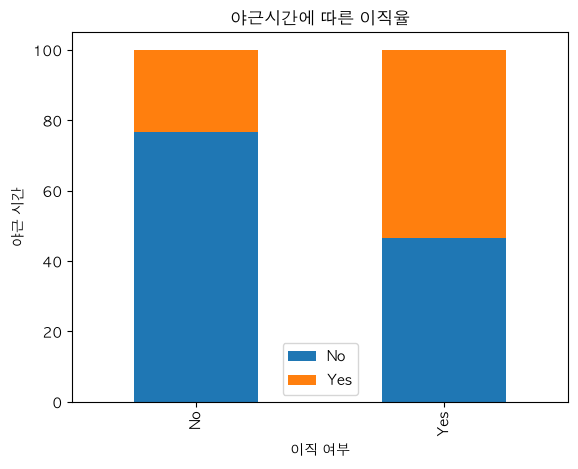

In [114]:
# 1. 야근(OverTime)을 하는 직원과 하지 않는 직원의 이직(Attrition) 비율은 얼마나 차이가 나는지 그래프로 나타내고 분석 결과를 서술하세요.

# - 집계 및 시각화: OverTime별 Attrition 비율(백분율, %)을 계산하고, 수치 차이가 대비되는 누적/그룹 그래프를 생성하세요.


result = (
    pd.crosstab(hr_df["Attrition"], hr_df["OverTime"], normalize = "index") * 100
)

print(result)
result.plot(kind = "bar", stacked = True)
# sns.barplot(data=)



plt.title("야근시간에 따른 이직율")
plt.xlabel("이직 여부")
plt.ylabel("야근 시간")
plt.legend()
plt.show()


"""
    이직을 선택한 사람들의 야근시간이 더 높은 것으로 보아 야근시간이 길어질수록 이직할 확률은 올라간다고 볼 수 잇다.
"""
None

이직집단과 잔류 집단 별 평균 월 소득 :                   mean
Attrition             
No         6832.739659
Yes        4787.092827원


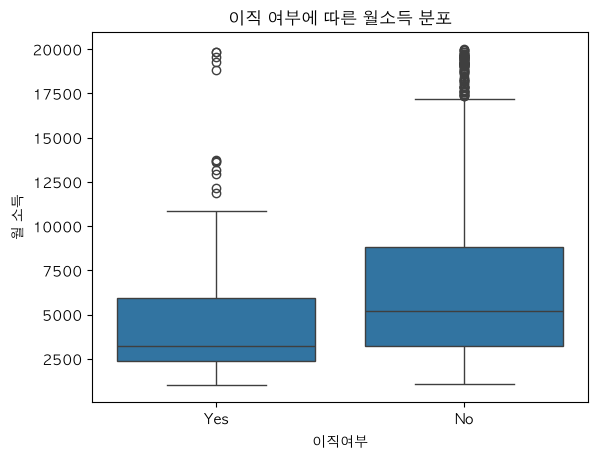

In [120]:
# 2. 이직한 직원(Yes)과 잔류한 직원(No)의 월소득(MonthlyIncome) 평균 및 분포(Boxplot)에는 어떤 차이가 있는지 결과를 분석하고 그래프로 나타내고 서술하세요,

# - 이직 집단(Yes)과 잔류 집단(No)의 평균 월소득을 각각 산출하고, 소득의 분포와 이상치를 한눈에 파악할 수 있는 그래프를 생성하세요.

result = hr_df.groupby("Attrition")["MonthlyIncome"].agg(["mean"])
print(f"이직집단과 잔류 집단 별 평균 월 소득 : {result}원")

sns.boxplot(data = hr_df, x = "Attrition", y = "MonthlyIncome")
plt.title("이직 여부에 따른 월소득 분포")
plt.xlabel("이직여부")
plt.ylabel("월 소득")
plt.show()

"""
    이직을 선택한 직원들의 월소득 분포는 이직을 하지 않은 직원들보다 낮은 곳에 형성되어있기 때문에 월소득은 이직여부에 영향을 끼친다고 생각이 가능하다.
"""
None

    YearsSinceLastPromotion   Yes_rate     No_rate
0                         0  18.932874   81.067126
1                         1  13.725490   86.274510
2                         2  16.981132   83.018868
3                         3  17.307692   82.692308
4                         4   8.196721   91.803279
5                         5   4.444444   95.555556
6                         6  18.750000   81.250000
7                         7  21.052632   78.947368
8                         8   0.000000  100.000000
9                         9  23.529412   76.470588
10                       10  16.666667   83.333333
11                       11   8.333333   91.666667
12                       12   0.000000  100.000000
13                       13  20.000000   80.000000
14                       14  11.111111   88.888889
15                       15  23.076923   76.923077


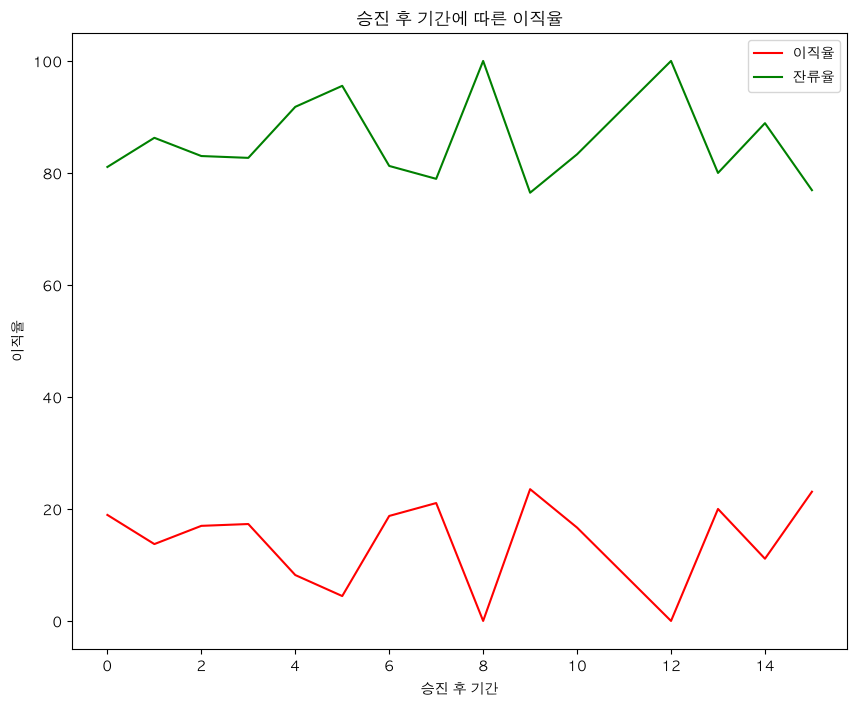

In [121]:
# 3. 마지막 승진 후 기간(YearsSinceLastPromotion)이 길어질수록 이직률이 높아진다는 가설이 맞는지 결과를 분석하고 그래프로 나타내고 서술하세요,

# - 마지막 승진 후 기간별 이직률(%)을 집계하고, 변화 흐름을 파악하기 적합한 그래프를 생성하세요.

result = (hr_df.groupby("YearsSinceLastPromotion")["Attrition"].agg(Yes_rate = (lambda x : (x == "Yes").mean() * 100), No_rate = (lambda x : (x == "No").mean() * 100)).reset_index())

print(result)

plt.figure(figsize = (10, 8))
# result.plot(kind = "line")
sns.lineplot(data = result, x = "YearsSinceLastPromotion", y = "Yes_rate", color= "red", label = "이직율")
sns.lineplot(data = result, x = "YearsSinceLastPromotion", y = "No_rate", color = "green", label = "잔류율" )

plt.title("승진 후 기간에 따른 이직율")
plt.xlabel("승진 후 기간")
plt.ylabel("이직율")
plt.legend()
plt.show()

"""
    기간에 따른 이직율의 차이는 존재하지만 우상향하는 형태가 아니고 년차별로 변화하기 때문에 승진 후 기간이 꼭 이직에 영향을 끼친다고 볼 수는 없다.
"""
None

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


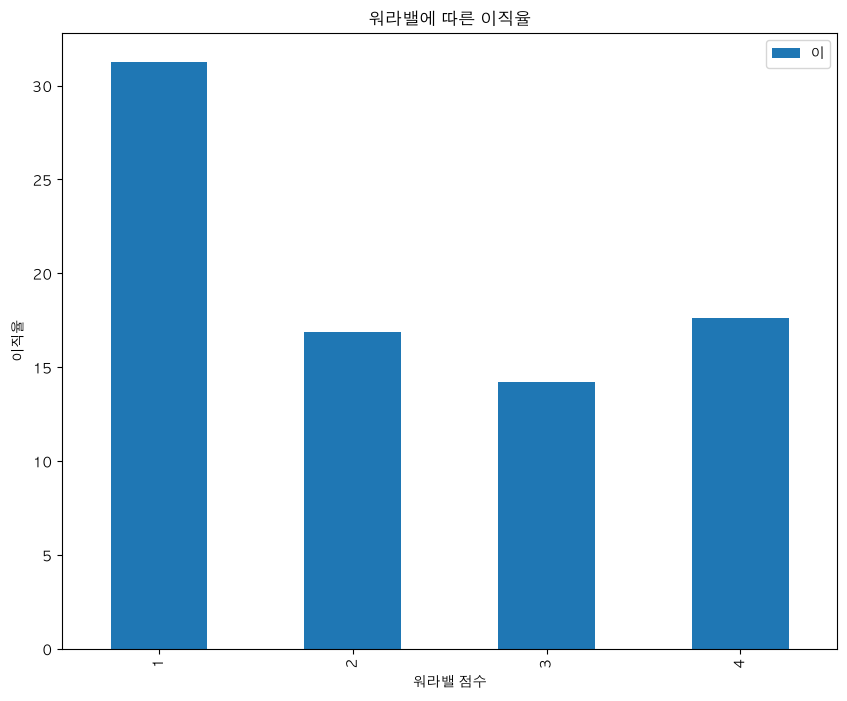

In [127]:
# 4. 워라밸 만족도(WorkLifeBalance: 1~4점) 점수별 이직률을 구하고, 워라밸이 낮을 때(1점)의 이직 위험도를 분석하고 그래프로 나타내고 서술하세요,

# - WorkLifeBalance 척도(1점: Bad ~ 4점: Best)별 이직률(%)을 구하고, 그룹 간 크기 비교에 적합한 그래프를 생성하세요.

wlb_result = hr_df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x : (x == "Yes").mean() * 100)

print(wlb_result)

plt.figure(figsize = (10, 8))
wlb_result.plot(kind = "bar")
plt.title("워라밸에 따른 이직율")
plt.xlabel("워라밸 점수")
plt.ylabel("이직율")
plt.legend("이직율")
plt.show()

"""
    워라밸 래벨이 1인 곳에 이직율이 가장높고 2~3래벨인 경우는 비슷한것으로 보아 워라밸이 가장 좋지 않은곳은 확실히 이직에 영향을 끼치지만 그 이상의 워라밸의 경우는 영향이 비슷함을 알 수있다/
"""
None